In [1]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
import matplotlib.pyplot as plt
from adjustText import adjust_text
import contextily as cx

In [2]:
# ------- Paths -------
data_caravan       = Path("/inputs/data_updated_2/time_series")
attributes_caravan = Path("/inputs/data_updated_2/attributes/attributes_other.csv")
basins_path        = Path("../../2_final_runs/1_531_caravan_vs_camels/2_531_basin.txt")
ATTRIBUTES_FILE    = Path("/inputs/data_updated_2/attributes/attributes_caravan.csv")

camels_metrics_dir = Path("../../2_final_runs/1_531_caravan_vs_camels/ensemble_metrics/"
                           "camels_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5.csv")
caravan_metrics_dir = Path("../../2_final_runs/1_531_caravan_vs_camels/ensemble_metrics/"
                            "total_precipitation_sum_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5.csv")

In [3]:
with open(basins_path, "r") as f:
    basins = f.read().splitlines()

In [4]:
location_531 = pd.read_csv(attributes_caravan)
location_531 = location_531[location_531["gauge_id"].isin(basins)]
location_531.head()

,gauge_id,gauge_name,country,gauge_lat,gauge_lon,area
1,camels_01022500,"Narraguagus River at Cherryfield, Maine",United States of America,44.60797,-67.93524,619.102595
3,camels_01031500,"Piscataquis River near Dover-Foxcroft, Maine",United States of America,45.17501,-69.31470,764.824149
4,camels_01047000,"Carrabassett River near North Anson, Maine",United States of America,44.86920,-69.95510,902.895076
5,camels_01052500,"Diamond River near Wentworth Location, NH",United States of America,44.87739,-71.05749,395.444910
6,camels_01054200,"Wild River at Gilead, Maine",United States of America,44.39044,-70.97964,180.835783


In [5]:
camels_metrics = pd.read_csv(camels_metrics_dir)
caravan_metrics = pd.read_csv(caravan_metrics_dir)

In [6]:
camels_metrics.head()

,basin_id,NSE,MSE,RMSE,KGE,Alpha-NSE,Pearson-r,Beta-KGE,Beta-NSE,FHV,FMS,FLV,Peak-Timing,Missed-Peaks,Peak-MAPE
0,camels_01022500,0.873195,0.788830,0.888161,0.862428,0.898171,0.937404,0.931892,-0.063178,-8.366964,-3.287585,21.083689,0.181818,0.218750,23.027092
1,camels_01031500,0.888100,1.148055,1.071473,0.849362,0.859370,0.946412,0.993412,-0.004485,-13.875319,-9.154499,43.207787,0.181818,0.121212,27.374205
2,camels_01047000,0.875006,1.496363,1.223259,0.856017,0.875586,0.937855,0.962715,-0.026249,-12.341771,-3.645504,-7.947985,0.090909,0.324324,23.634581
3,camels_01052500,0.885470,1.410681,1.187721,0.891121,0.997709,0.944424,1.093598,0.060219,-1.528729,-5.378186,28.173573,0.083333,0.184211,26.958374
4,camels_01054200,0.657618,11.366599,3.371439,0.594510,0.635551,0.836159,0.931040,-0.036060,-36.622028,-4.827666,-7.782070,0.250000,0.210526,44.101734


In [7]:
caravan_metrics.head()

,basin_id,NSE,MSE,RMSE,KGE,Alpha-NSE,Pearson-r,Beta-KGE,Beta-NSE,FHV,FMS,FLV,Peak-Timing,Missed-Peaks,Peak-MAPE
0,camels_01022500,0.749536,1.558084,1.248233,0.867014,0.998797,0.875566,0.953097,-0.043508,3.069363,-6.344704,41.908733,0.272727,0.281250,36.178741
1,camels_01031500,0.800767,2.044064,1.429708,0.847784,0.901590,0.895543,1.050733,0.034540,-8.391373,-16.757488,64.915009,0.272727,0.181818,30.384523
2,camels_01047000,0.761448,2.855816,1.689916,0.752403,0.802424,0.877956,0.914132,-0.060452,-17.735838,-13.208194,18.773703,0.363636,0.270270,35.831432
3,camels_01052500,0.841340,1.954236,1.397940,0.867342,0.897413,0.917528,1.016505,0.010619,-9.976896,-10.814296,46.969646,0.166667,0.315789,33.657455
4,camels_01054200,0.603612,13.159534,3.627607,0.557595,0.617607,0.799534,0.903505,-0.050458,-39.208607,-6.626186,7.239662,0.500000,0.368421,51.915413


In [8]:
# caravan basin_id is already in the right format, just rename
camels_metrics['gauge_id'] = camels_metrics['basin_id'] 
# camels_metrics['gauge_id'] = 'camels_' + camels_metrics['basin_id'].astype(str).str.zfill(8)
caravan_metrics['gauge_id'] = caravan_metrics['basin_id']

# Merge only ensemble_nse columns
location_531 = location_531.merge(
    camels_metrics[['gauge_id', 'NSE']].rename(columns={'NSE': 'camels_nse'}),
    on='gauge_id', how='left'
).merge(
    caravan_metrics[['gauge_id', 'NSE']].rename(columns={'NSE': 'caravan_nse'}),
    on='gauge_id', how='left'
)


In [9]:
location_531.head()

,gauge_id,gauge_name,country,gauge_lat,gauge_lon,area,camels_nse,caravan_nse
0,camels_01022500,"Narraguagus River at Cherryfield, Maine",United States of America,44.60797,-67.93524,619.102595,0.873195,0.749536
1,camels_01031500,"Piscataquis River near Dover-Foxcroft, Maine",United States of America,45.17501,-69.31470,764.824149,0.888100,0.800767
2,camels_01047000,"Carrabassett River near North Anson, Maine",United States of America,44.86920,-69.95510,902.895076,0.875006,0.761448
3,camels_01052500,"Diamond River near Wentworth Location, NH",United States of America,44.87739,-71.05749,395.444910,0.885470,0.841340
4,camels_01054200,"Wild River at Gilead, Maine",United States of America,44.39044,-70.97964,180.835783,0.657618,0.603612


In [10]:
# Map both NSE values to the dataframe
location_531['nse_dif'] = location_531['caravan_nse'] - location_531['camels_nse']
location_531.head()

,gauge_id,gauge_name,country,gauge_lat,gauge_lon,area,camels_nse,caravan_nse,nse_dif
0,camels_01022500,"Narraguagus River at Cherryfield, Maine",United States of America,44.60797,-67.93524,619.102595,0.873195,0.749536,-0.123658
1,camels_01031500,"Piscataquis River near Dover-Foxcroft, Maine",United States of America,45.17501,-69.31470,764.824149,0.888100,0.800767,-0.087333
2,camels_01047000,"Carrabassett River near North Anson, Maine",United States of America,44.86920,-69.95510,902.895076,0.875006,0.761448,-0.113558
3,camels_01052500,"Diamond River near Wentworth Location, NH",United States of America,44.87739,-71.05749,395.444910,0.885470,0.841340,-0.044130
4,camels_01054200,"Wild River at Gilead, Maine",United States of America,44.39044,-70.97964,180.835783,0.657618,0.603612,-0.054006


In [11]:
gdf_531 = gpd.GeoDataFrame(
    location_531,
    geometry=gpd.points_from_xy(location_531['gauge_lon'], location_531['gauge_lat']),
    crs='EPSG:4326'
)
gdf_531.head()

,gauge_id,gauge_name,country,gauge_lat,gauge_lon,area,camels_nse,caravan_nse,nse_dif,geometry
0,camels_01022500,"Narraguagus River at Cherryfield, Maine",United States of America,44.60797,-67.93524,619.102595,0.873195,0.749536,-0.123658,POINT (-67.93524 44.60797)
1,camels_01031500,"Piscataquis River near Dover-Foxcroft, Maine",United States of America,45.17501,-69.31470,764.824149,0.888100,0.800767,-0.087333,POINT (-69.3147 45.17501)
2,camels_01047000,"Carrabassett River near North Anson, Maine",United States of America,44.86920,-69.95510,902.895076,0.875006,0.761448,-0.113558,POINT (-69.9551 44.8692)
3,camels_01052500,"Diamond River near Wentworth Location, NH",United States of America,44.87739,-71.05749,395.444910,0.885470,0.841340,-0.044130,POINT (-71.05749 44.87739)
4,camels_01054200,"Wild River at Gilead, Maine",United States of America,44.39044,-70.97964,180.835783,0.657618,0.603612,-0.054006,POINT (-70.97964 44.39044)


In [12]:
attributes_df = pd.read_csv(ATTRIBUTES_FILE)
# attributes_df.head()

In [13]:
gdf_531["frac_snow"]=gdf_531['gauge_id'].map(attributes_df.set_index('gauge_id')['frac_snow'])
# gdf_531.head()

In [14]:
# Define CONUS bounds in lat/lon
conus_bounds = box(-125, 24, -66.5, 50)  # (minx, miny, maxx, maxy)

# Convert to GeoDataFrame and project to Web Mercator
conus_gdf = gpd.GeoDataFrame(geometry=[conus_bounds], crs="EPSG:4326")
conus_gdf_web = conus_gdf.to_crs(epsg=3857)

# Extract projected bounds
xmin, ymin, xmax, ymax = conus_gdf_web.total_bounds

127


[]

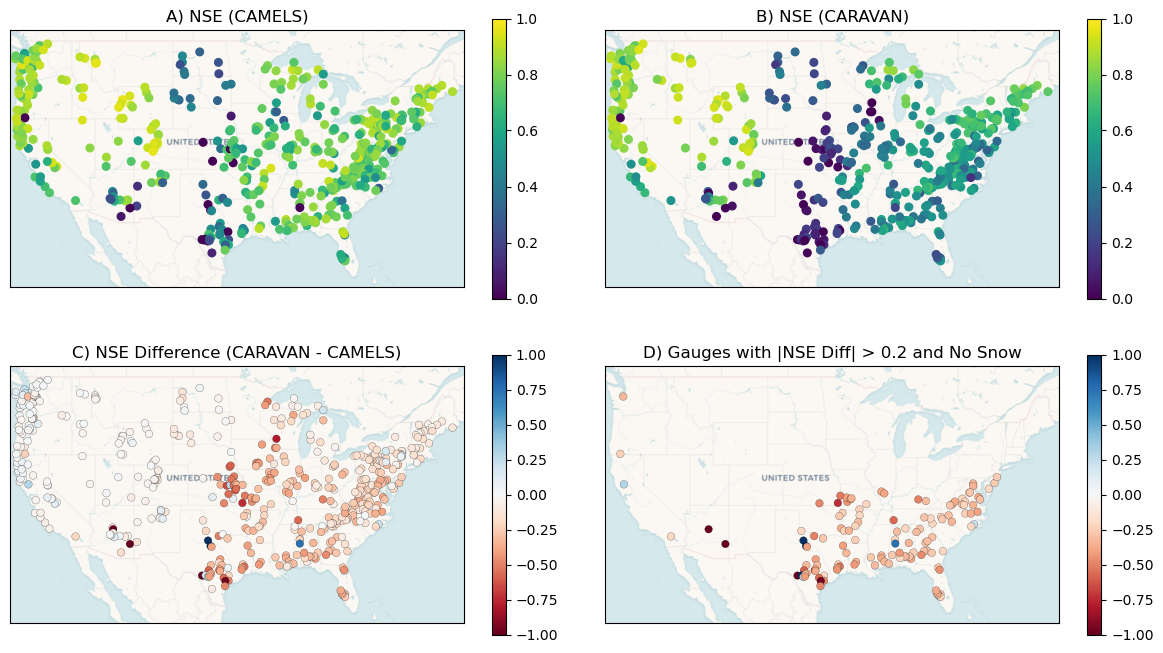

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(15, 8))
plt.subplots_adjust(wspace=0.05)

gdf_531_webmercator = gdf_531.to_crs(epsg=3857)

# ---------------- Plot 1: CAMELS NSE ----------------
gdf_531_webmercator.plot(
    column='camels_nse',
    cmap='viridis',
    legend=True,
    markersize=30,
    ax=ax[0, 0],
    vmin=0,
    vmax=1
)
# cbar = ax[0, 0].get_figure().get_axes()[1]
# cbar.set_ylabel("NSE (CAMELS)", rotation=270, labelpad=15)
ax[0, 0].set_title("A) NSE (CAMELS)")
ax[0, 0].set_xlim(xmin, xmax)
ax[0, 0].set_ylim(ymin, ymax)
cx.add_basemap(ax[0, 0], source=cx.providers.CartoDB.Voyager, attribution=False)
ax[0,0].set_xticks([])
ax[0,0].set_yticks([])

# ---------------- Plot 2: CARAVAN NSE ----------------
gdf_531_webmercator.plot(
    column='caravan_nse',
    cmap='viridis',
    legend=True,
    markersize=30,
    ax=ax[0, 1],
    vmin=0,
    vmax=1
)
# cbar = ax[0, 1].get_figure().get_axes()[1]
# cbar.set_ylabel("NSE (CARAVAN)", rotation=270, labelpad=15)
ax[0, 1].set_title("B) NSE (CARAVAN)")
ax[0, 1].set_xlim(xmin, xmax)
ax[0, 1].set_ylim(ymin, ymax)
cx.add_basemap(ax[0, 1], source=cx.providers.CartoDB.Voyager, attribution=False)
ax[0,1].set_xticks([])
ax[0,1].set_yticks([])

# ---------------- Plot 3: NSE Difference ----------------
gdf_531_webmercator.plot(
    column='nse_dif',
    cmap='RdBu',
    legend=True,
    markersize=30,
    ax=ax[1, 0],
    vmin=-1,
    vmax=1,
    edgecolor='black',
    linewidth=0.15
)

# cbar = ax[1, 0].get_figure().get_axes()[1]
ax[1, 0].set_title("C) NSE Difference (CARAVAN - CAMELS)")
ax[1, 0].set_xlim(xmin, xmax)
ax[1, 0].set_ylim(ymin, ymax)
cx.add_basemap(ax[1, 0], source=cx.providers.CartoDB.Voyager, attribution=False)
ax[1,0].set_xticks([])
ax[1,0].set_yticks([])

# ---------------- Plot 4: NSE Difference > 0.2 (absolute filter, original values) ----------------
gdf_large_diff = gdf_531_webmercator[
    (gdf_531_webmercator['nse_dif'].abs() > 0.2) &
    (gdf_531_webmercator['frac_snow'] == 0)
]
print(gdf_large_diff.shape[0])

gdf_large_diff.plot(
    column='nse_dif',
    cmap='RdBu',
    legend=True,
    markersize=30,
    ax=ax[1, 1],
    vmin=-1,
    vmax=1,
    edgecolor='black',
    linewidth=0.15
)

# cbar = ax[1, 1].get_figure().get_axes()[1]
ax[1, 1].set_title("D) Gauges with |NSE Diff| > 0.2 and No Snow")
ax[1, 1].set_xlim(xmin, xmax)
ax[1, 1].set_ylim(ymin, ymax)
cx.add_basemap(ax[1, 1], source=cx.providers.CartoDB.Voyager, attribution=False)
ax[1,1].set_xticks([])
ax[1,1].set_yticks([])

In [16]:
gdf_large_diff['gauge_id'].to_csv('basins_subset_test.txt', index=False, header=False)

In [17]:
gdf_large_diff.nsmallest(10, "nse_dif")

,gauge_id,gauge_name,country,gauge_lat,gauge_lon,area,camels_nse,caravan_nse,nse_dif,geometry,frac_snow
385,camels_08190500,"W Nueces Rv nr Brackettville, TX",United States of America,29.47273,-100.23646,1802.554602,-128.374451,-258.498413,-130.123962,POINT (-11158271.686 3435952.666),0.0
417,camels_09447800,"BONITA CREEK NEAR MORENCI, AZ.",United States of America,32.95562,-109.53119,777.495127,-0.717972,-2.639908,-1.921936,POINT (-12192956.297 3889414.741),0.0
423,camels_09505800,"WEST CLEAR CREEK NEAR CAMP VERDE, AZ.",United States of America,34.53864,-111.69404,625.077280,0.330465,-1.286843,-1.617307,POINT (-12433723.657 4101359.579),0.0
381,camels_08176900,"Coleto Ck at Arnold Rd nr Schroeder, TX",United States of America,28.86165,-97.22638,926.448541,0.291239,-0.682639,-0.973879,POINT (-10823191.113 3358048.937),0.0
374,camels_08158700,"Onion Ck nr Driftwood, TX",United States of America,30.08299,-98.00779,321.850708,0.879078,0.128408,-0.750671,POINT (-10910177.277 3514221.901),0.0
339,camels_07184000,"LIGHTNING C NR MCCUNE, KS",United States of America,37.28125,-95.03267,514.638422,0.750759,0.016363,-0.734395,POINT (-10578988.433 4478382.253),0.0
378,camels_08165300,"N Fk Guadalupe Rv nr Hunt, TX",United States of America,30.06410,-99.38699,440.334604,0.710664,0.110131,-0.600532,POINT (-11063709.118 3511791.965),0.0
220,camels_03604000,"BUFFALO RIVER NEAR FLAT WOODS, TN",United States of America,35.49591,-87.83280,1163.665932,0.861677,0.284459,-0.577217,POINT (-9777502.571 4231479.223),0.0
380,camels_08175000,"Sandies Ck nr Westhoff, TX",United States of America,29.21525,-97.44943,1427.336029,0.616859,0.050068,-0.566790,POINT (-10848020.926 3403071.167),0.0
363,camels_08066300,"Menard Ck nr Rye, TX",United States of America,30.48139,-94.77972,391.214743,0.464678,-0.088176,-0.552855,POINT (-10550830.168 3565579.339),0.0
